## Double Homograohy On Chess Board

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
import math
from sklearn.cluster import KMeans
import numpy as np
from sklearn.cluster import DBSCAN
import itertools
import json



### Preprocessing Image

In [2]:

def resize_image(img, max_width=1024):
    """
    Resizes image to a maximum width of 10024 pixels, maintaining aspect ratio.
    """
    h, w = img.shape[:2]
    if w > max_width:
        scale = max_width / float(w)
        return cv2.resize(img, (int(w*scale), int(h*scale)))
    return img

def show_image_debug(title, img, points=None, Hlines=None, Vlines=None, treat_lines_as_infinite=False, size=7):
    """
    Display an image during processing with optional overlays. 
    It now expects Hlines/Vlines to be in the robust (N, 4) format: [x1, y1, x2, y2].
    """
    display_img = img.copy()
    h, w = display_img.shape[:2]

    def draw_lines(lines, color, treat_infinite=False):
        if lines is None: return
        # Ensure lines is an N x 4 array and handle empty arrays
        lines = np.atleast_2d(lines) 
        if lines.size == 0: return
            
        for line in lines:
            x1, y1, x2, y2 = line.astype(int) 
            if treat_infinite:
                if abs(x2 - x1) < 1:
                    cv2.line(display_img, (x1, 0), (x1, h), color, 2)
                    continue
                slope = (y2 - y1) / (x2 - x1)
                intercept = y1 - slope * x1
                if abs(y2 - y1) < 1:
                    cv2.line(display_img, (0, y1), (w, y1), color, 2)
                    continue
                y_start = int(slope * 0 + intercept)
                y_end = int(slope * w + intercept)
                cv2.line(display_img, (0, y_start), (w, y_end), color, 2)
            else:
                cv2.line(display_img, (x1, y1), (x2, y2), color, 2)

    draw_lines(Hlines, (0, 255, 0), treat_lines_as_infinite)
    
    draw_lines(Vlines, (255, 0, 0), treat_lines_as_infinite)
    
    
    plt.figure(figsize=(size, size))

    if len(display_img.shape) == 3:
        plt.imshow(cv2.cvtColor(display_img, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(display_img, cmap='gray')
    if points is not None:
        pts = np.array(points)
        plt.scatter(pts[:, 0], pts[:, 1], c='red', s=30)

    plt.title(title)
    plt.axis('off')
    plt.show()

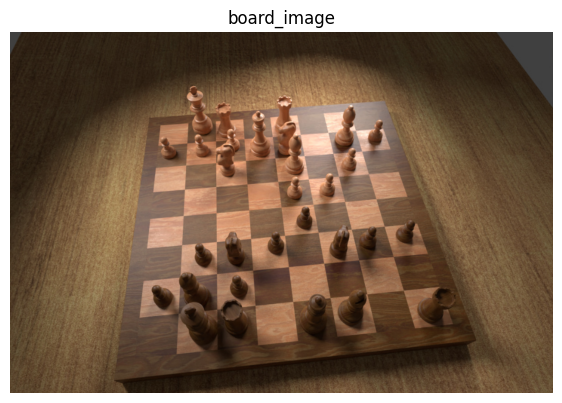

In [3]:
src_path = 'boards/board0.jpg'
#src_path = 'boards/board0.jpg'
#reading image
image = cv2.imread(src_path)
#resozing for max length
image = resize_image(image)
#display image
show_image_debug("board_image", image)

In [4]:


def pre_processing_pipeline(img, threshold1=50, threshold2=70, dil_iter=1):
    #applying grayscale
    output = img.copy()
    if len(img.shape) == 3: output = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    #applying gaussian blur
    output = cv2.GaussianBlur(output, (5, 5), 0)
    #canny edge detector
    #process = cv2.Canny(process, 50, 70)
    output = cv2.Canny(output, threshold1, threshold2)
    #dilation
    output = cv2.dilate(output, None, iterations=1) 

    return output


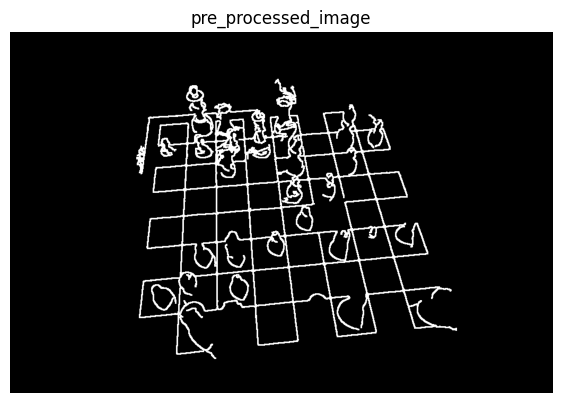

In [5]:
processes_image = pre_processing_pipeline(image, threshold1=10, threshold2=200)
show_image_debug("pre_processed_image", processes_image)

### Detecting Lines Image

In [6]:
def detect_lines(img, hough_threshold=50, min_line_length=50, max_line_gap=20):
    """
    Detects line segments using HoughLinesP and returns them in the 
    desired (N, 4) format: [x1, y1, x2, y2].
    """
    lines = cv2.HoughLinesP(
        img, 
        2, 
        np.pi/180, 
        threshold=hough_threshold, 
        minLineLength=min_line_length, 
        maxLineGap=max_line_gap
    )    
    if lines is not None:
        return lines.reshape(-1, 4)
    else:
        return np.array([], dtype=np.int32).reshape(0, 4)


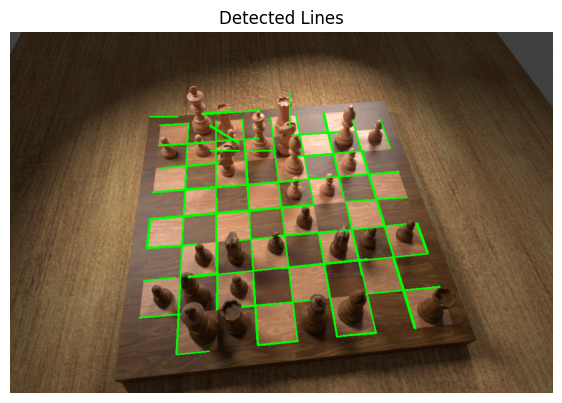

In [7]:
lines = detect_lines(processes_image, hough_threshold=100, min_line_length=50, max_line_gap=5)
show_image_debug("Detected Lines", image, Hlines=lines)

In [8]:
def visualize_dbscan_clusters(angles_deg, labels, title="DBSCAN Clustering of Line Angles"):
    """
    Creates a scatter plot of line angles colored by their DBSCAN cluster label.

    Args:
        angles_deg (np.array): 1D array of normalized line angles in degrees [0, 180).
        labels (np.array): 1D array of cluster labels assigned by DBSCAN.
        title (str): Title for the plot.
    """
    unique_labels = set(labels)
    n_clusters_ = len(unique_labels) - (1 if -1 in labels else 0)
    plt.figure(figsize=(10, 5))
    # Define color map for clusters
    colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
    # Iterate over unique labels (-1 is noise)
    for k, col in zip(unique_labels, colors):
        if k == -1:
            # Black used for noise.
            col = [0, 0, 0, 1]
            marker = 'x'
            s_size = 30
        else:
            marker = 'o'
            s_size = 50

        # Create a mask for the points belonging to the current cluster k
        class_member_mask = (labels == k)
        # Plot the points (angles) belonging to the cluster
        # We plot them on y=1 for a 1D visualization
        xy = angles_deg[class_member_mask]
        # Plot only the angles
        plt.scatter(xy, 
                    np.ones_like(xy), # Set all Y values to 1 for a single line plot
                    marker=marker, 
                    s=s_size, 
                    c=[col], 
                    label=f'Cluster {k}' if k != -1 else 'Noise',
                    zorder=3 # Ensure points are above grid
                   )
    plt.title(f'{title} (Estimated Clusters: {n_clusters_})')
    plt.xlabel('Normalized Line Angle (Degrees) [0° to 180°]')
    plt.yticks([]) # Remove Y-axis ticks since the plot is 1D
    plt.xlim(0, 180)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.legend(loc='upper right')
    plt.show()

In [9]:
def robust_chessboard_lines(lines, num_lines=4, angle_tolerance_deg=10, min_samples=3):
    """
    Clusters detected line segments into horizontal and vertical groups, 
    removes outliers using DBSCAN on angles, and selects the top 'num_lines' 
    based on line length.

    Args:
        num_lines (int): The number of top lines to select for each category.
        angle_tolerance_deg (float): The maximum angle difference (epsilon) for DBSCAN clustering, in degrees.
        min_samples (int): The minimum number of lines to form a cluster (DBSCAN).
    """
    if lines.shape[0] == 0: return np.array([]), np.array([])

    #get all dx dy
    dx = lines[:, 2] - lines[:, 0]
    dy = lines[:, 3] - lines[:, 1]
    # Calculate angles
    angles_rad = np.arctan2(dy, dx)
    angles_rad_normalized = angles_rad % np.pi
    angles_deg_normalized = np.degrees(angles_rad_normalized)
    X = angles_deg_normalized.reshape(-1, 1)
    # Calculate lengths
    lengths = np.sqrt(dx**2 + dy**2)
    
    # 2. Robust Clustering and Outlier Removal with DBSCAN    
    db = DBSCAN(eps=angle_tolerance_deg, min_samples=min_samples, metric='euclidean').fit(X)
    labels = db.labels_
    visualize_dbscan_clusters(angles_deg_normalized, labels)

    # Find the indices of the two largest clusters (Horizontal and Vertical)
    unique_labels = set(labels)
    cluster_labels = [l for l in unique_labels if l != -1] # Exclude noise
    
    if len(cluster_labels) < 2:
        print("Could not find two distinct clusters (Horizontal and Vertical). Returning all lines labeled as a cluster.")
        
        if len(cluster_labels) == 0:
             return np.array([]), np.array([])
             
        only_cluster_indices = np.where(labels == cluster_labels[0])[0]
        mean_angle = np.mean(angles_deg_normalized[only_cluster_indices])
        if np.abs(mean_angle - 90) < 45:
             return lines[only_cluster_indices], np.array([])
        else:
             return np.array([]), lines[only_cluster_indices]

    cluster_counts = {l: np.sum(labels == l) for l in cluster_labels}
    top_two_clusters = sorted(cluster_counts, key=cluster_counts.get, reverse=True)[:2]

    cluster_1_indices = np.where(labels == top_two_clusters[0])[0]
    cluster_2_indices = np.where(labels == top_two_clusters[1])[0]

    mean_angle_1 = np.mean(angles_deg_normalized[cluster_1_indices])
    mean_angle_2 = np.mean(angles_deg_normalized[cluster_2_indices])
    
    dist_to_90_1 = np.abs(mean_angle_1 - 90)
    dist_to_90_2 = np.abs(mean_angle_2 - 90)

    if dist_to_90_1 < dist_to_90_2:
        vertical_indices = cluster_1_indices
        horizontal_indices = cluster_2_indices
    else:
        vertical_indices = cluster_2_indices
        horizontal_indices = cluster_1_indices

    # 4. Line Selection: Ranking by Length
    def select_top_lines(indices, num_lines_limit):
        """Ranks lines by length and selects the top 'num_lines_limit'."""
        if len(indices) == 0:
            return np.array([])
            
        cluster_lines = lines[indices]
        cluster_lengths = lengths[indices]
        # 1. Get indices sorted by length (descending)
        sorted_indices_in_cluster = np.argsort(cluster_lengths)[::-1]
        
        # 2. Determine the actual number of lines to select:
        # We take the MINIMUM of the requested limit and the available lines.
        # This is a safe guard.
        num_to_select = min(num_lines_limit, len(sorted_indices_in_cluster))
        
        # 3. Select the top indices using the calculated limit
        top_indices = sorted_indices_in_cluster[:num_to_select] 
        
        # 4. Return the selected lines
        return cluster_lines[top_indices]


    top_vertical_lines = select_top_lines(vertical_indices,num_lines_limit=num_lines)
    top_horizontal_lines = select_top_lines(horizontal_indices,num_lines_limit=num_lines)

    return top_vertical_lines, top_horizontal_lines

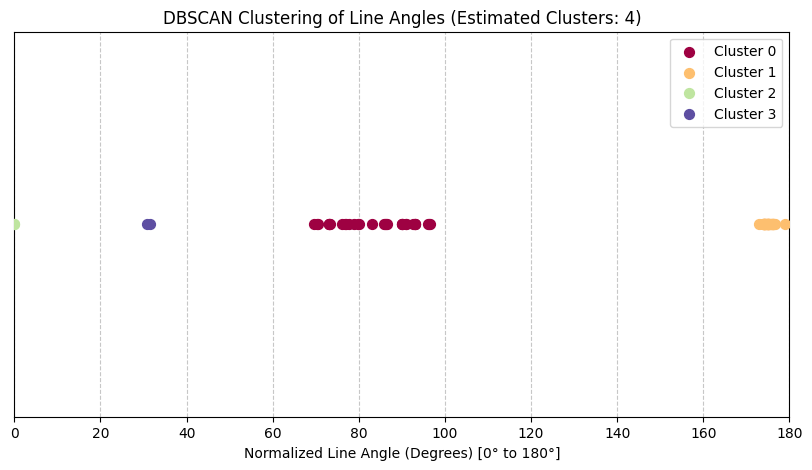

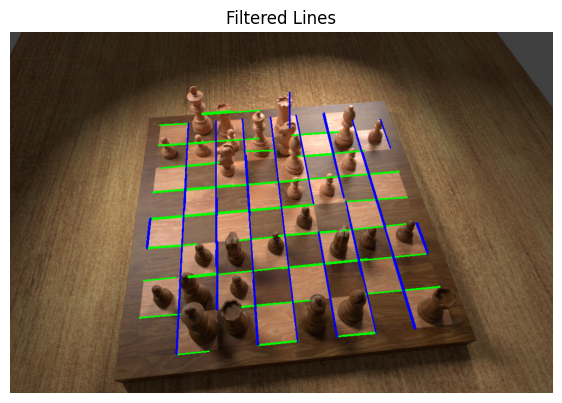

In [10]:
vertical_lines, horizontal_lines = robust_chessboard_lines(lines, num_lines=40, angle_tolerance_deg=10, min_samples=2)
show_image_debug("Filtered Lines", image, Hlines=horizontal_lines, Vlines=vertical_lines)

### Calculating Intersection And Applying First Homography

In [11]:
def compute_intersection(line1, line2):
    """
    Finds the intersection of two lines given in (x1, y1, x2, y2) format.
    Uses the cross product method (homogeneous coordinates).
    """
    # 1. Extract coordinates and force float to avoid integer overflow
    x1, y1, x2, y2 = map(float, line1)
    x3, y3, x4, y4 = map(float, line2)

    # 2. Compute the homogenous line representations
    # Line 1 passes through p1 and p2
    L1 = np.cross([x1, y1, 1], [x2, y2, 1])
    # Line 2 passes through p3 and p4
    L2 = np.cross([x3, y3, 1], [x4, y4, 1])

    # 3. The intersection point is the cross product of the two lines
    intersection = np.cross(L1, L2)

    # 4. Normalize (convert back from homogeneous to cartesian)
    if intersection[2] == 0:
        return None # Lines are parallel
    
    x = intersection[0] / intersection[2]
    y = intersection[1] / intersection[2]
    
    return [x, y]

In [12]:
def get_4_points(h_lines, v_lines):
    # Sort Horizontal lines by Y
    h_lines = sorted(h_lines, key=lambda l: (l[1] + l[3]) / 2)
    # Sort Vertical lines by X
    v_lines = sorted(v_lines, key=lambda l: (l[0] + l[2]) / 2)

    top_line = h_lines[0]
    bottom_line = h_lines[-1]
    left_line = v_lines[0]
    right_line = v_lines[-1]
    p_tl = compute_intersection(top_line, left_line)
    p_tr = compute_intersection(top_line, right_line)
    p_br = compute_intersection(bottom_line, right_line)
    p_bl = compute_intersection(bottom_line, left_line)    
    print("--- Intersection Debug ---")
    print(f"Top-Left:     {p_tl}")
    print(f"Top-Right:    {p_tr}")
    print(f"Bottom-Right: {p_br}")
    print(f"Bottom-Left:  {p_bl}")
    src_points = np.float32([p_tl, p_tr, p_br, p_bl])
    return src_points
    
def warp_to_chessboard_plane(image, inter_points, output_size=(640, 640), padding_pct=0.2):
    # --- Step 3: Define Destination Points ---
    # We map these to a square in the new image, but with PADDING 
    # so we don't cut off the rest of the board.
    
    w, h = output_size
    pad_w = w * padding_pct
    pad_h = h * padding_pct
    
    # Define the box inside the destination image where the detected grid will go
    dst_points = np.float32([
        [pad_w, pad_h],         # Top-Left
        [w - pad_w, pad_h],     # Top-Right
        [w - pad_w, h - pad_h], # Bottom-Right
        [pad_w, h - pad_h]      # Bottom-Left
    ])

    # --- Step 4: Compute Homography and Warp ---
    # Calculate the Homography Matrix
    M = cv2.getPerspectiveTransform(inter_points, dst_points)
    
    # Warp the image
    warped_img = cv2.warpPerspective(image, M, output_size)
    
    return warped_img, M



--- Intersection Debug ---
Top-Left:     [284.7576582709326, 161.80735194009532]
Top-Right:    [684.124845488257, 126.1495673671199]
Bottom-Right: [837.8965517241379, 556.7103448275863]
Bottom-Left:  [233.206106870229, 617.1793893129772]


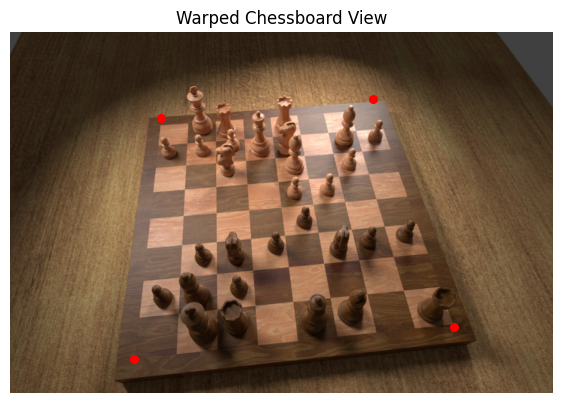

In [13]:
corner_pts = get_4_points(horizontal_lines, vertical_lines)
show_image_debug("Warped Chessboard View", image,points=corner_pts)

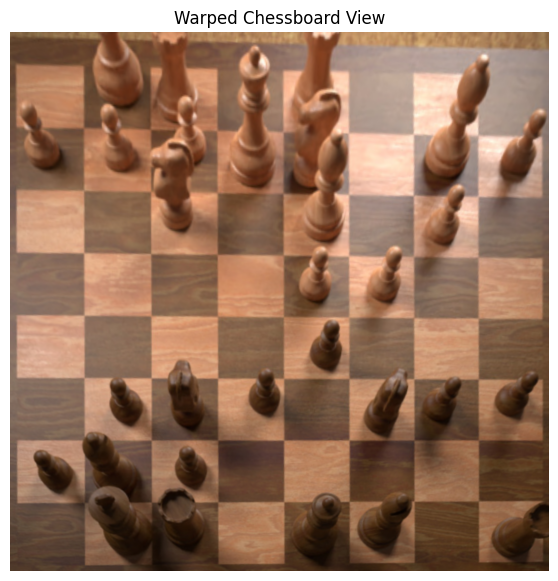

In [14]:
wrapped_image, H = warp_to_chessboard_plane(image, corner_pts, output_size=(1024, 1024), padding_pct=0.01)
H_inv = np.linalg.inv(H)
show_image_debug("Warped Chessboard View", wrapped_image)

### Second Homography

In [15]:
def split_lines_hv(lines, angle_tolerance_deg=5):
    """
    Splits lines into horizontal and vertical groups based on their angle.
    Assumes lines are in [x1, y1, x2, y2] format.
    """
    h_lines = []
    v_lines = []
    
    # Convert tolerance to radians
    tolerance_rad = np.deg2rad(angle_tolerance_deg)
    
    for line in lines:
        x1, y1, x2, y2 = line.flatten()
        
        # Calculate angle (theta) of the line segment
        angle_rad = np.arctan2(y2 - y1, x2 - x1)
        
        # Normalize angle to be between 0 and pi (or -pi/2 and pi/2 for direction)
        # Using np.abs(angle_rad) % (np.pi / 2) helps check proximity to 0 or 90 degrees
        
        # Check for Horizontal (Angle close to 0 or pi)
        # np.pi is 180 degrees
        if (np.abs(angle_rad) < tolerance_rad) or (np.abs(angle_rad - np.pi) < tolerance_rad):
            h_lines.append(line)
        # Check for Vertical (Angle close to pi/2 or -pi/2)
        elif (np.abs(angle_rad - np.pi/2) < tolerance_rad) or (np.abs(angle_rad + np.pi/2) < tolerance_rad):
            v_lines.append(line)

    # Convert back to NumPy arrays
    h_lines = np.array(h_lines, dtype=np.float32)
    v_lines = np.array(v_lines, dtype=np.float32)
    
    return h_lines, v_lines

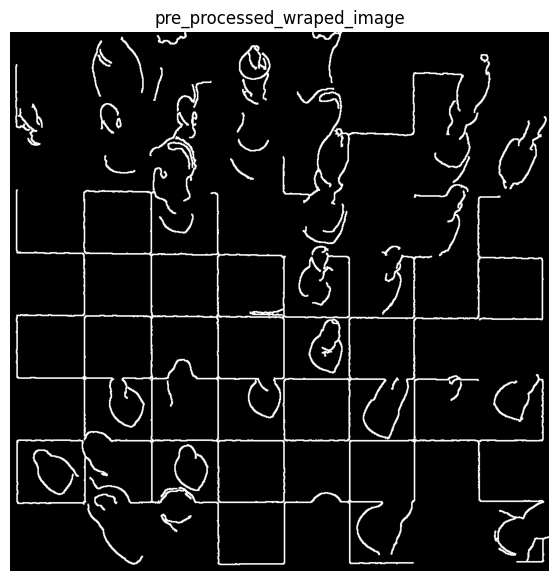

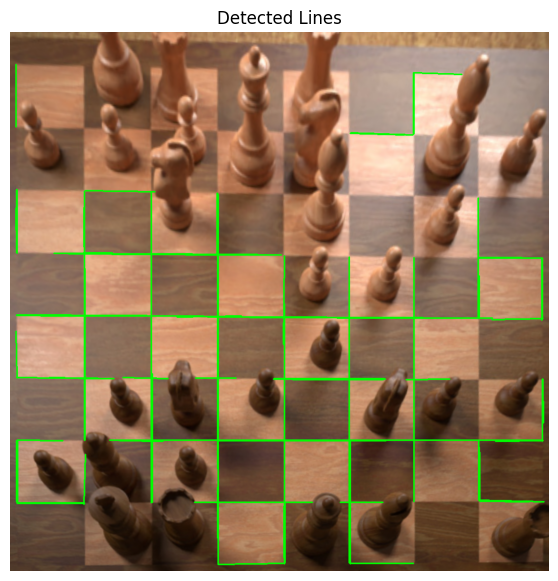

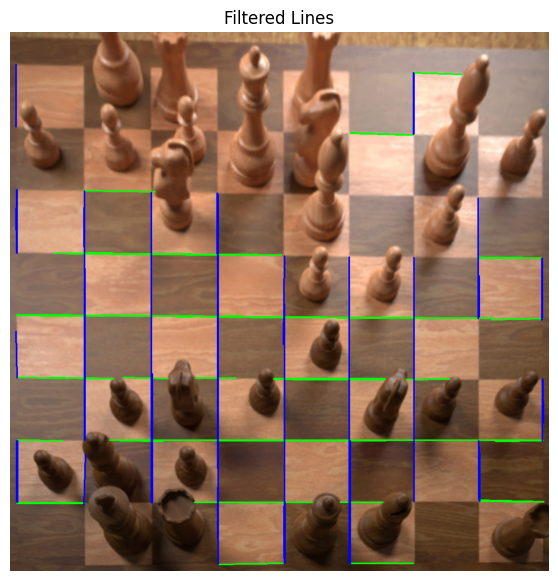

In [16]:
wrapped_image_processed = pre_processing_pipeline(wrapped_image, threshold1=10, threshold2=150)
show_image_debug("pre_processed_wraped_image", wrapped_image_processed)

wrapped_lines = detect_lines(wrapped_image_processed, hough_threshold=100, min_line_length=75, max_line_gap=3)
show_image_debug("Detected Lines", wrapped_image, Hlines=wrapped_lines)

wrapped_horizontal_lines, wrapped_vertical_lines = split_lines_hv(wrapped_lines, angle_tolerance_deg=5)
show_image_debug("Filtered Lines", wrapped_image, Hlines=wrapped_horizontal_lines, Vlines=wrapped_vertical_lines)


In [17]:
def collapse_and_average_lines(lines, dimension_index, grouping_threshold=15, num_lines=9):
    """
    Groups line segments that are close together and returns the mean position 
    for the top 'num_lines' groups.
    
    lines: The list/array of line segments (N, 4) in [x1, y1, x2, y2] format.
    dimension_index: 0 for vertical lines (checking X), 1 for horizontal lines (checking Y).
    grouping_threshold: Max pixel distance for lines to be considered the same (e.g., 15 pixels).
    num_lines: The expected final number of unique lines (must be 9 for a chessboard).
    """
    if len(lines) == 0:
        return np.array([])

    # 1. Calculate the position (P) for each line
    # P = Average of the coordinate in the specified dimension: (coord1 + coord2) / 2
    # For Vertical (index 0): P = (x1 + x2) / 2
    # For Horizontal (index 1): P = (y1 + y2) / 2
    positions = (lines[:, dimension_index] + lines[:, dimension_index + 2]) / 2
    
    # 2. Combine position with the original line for sorting
    combined = np.hstack((positions.reshape(-1, 1), lines))
    
    # 3. Sort primarily by position (X or Y)
    combined = combined[combined[:, 0].argsort()]
    
    # 4. Collapse/Cluster Lines
    final_positions = []
    current_cluster = []
    
    if len(combined) > 0:
        # Start the first cluster
        current_cluster.append(combined[0, 0])
        
        for i in range(1, len(combined)):
            current_pos = combined[i, 0]
            last_pos_in_cluster = current_cluster[-1]
            
            # If the current line is close to the last one in the cluster, add it
            if np.abs(current_pos - last_pos_in_cluster) < grouping_threshold:
                current_cluster.append(current_pos)
            else:
                # New cluster starts: Average the old cluster and save the position
                final_positions.append(np.mean(current_cluster))
                current_cluster = [current_pos]
        
        # Don't forget the final cluster
        if current_cluster:
            final_positions.append(np.mean(current_cluster))

    # 5. Optional: Enforce 9 lines
    # If more than 9 lines are found, this likely means the threshold was too small.
    # We take the top 9 most distinct lines based on the initial clustering.
    if len(final_positions) != num_lines:
        print(f"Warning: Found {len(final_positions)} clusters, expected {num_lines}. Check 'grouping_threshold'.")
        # If we found too many, take the 9 widest spread clusters
        if len(final_positions) > num_lines:
             # Simplest way: just take the first 9 unique positions, but better would be to re-cluster
             # For now, we rely on the next step (Regularization) to fix missing lines.
             pass

    # Return the mean positions (e.g., 9 distinct X coordinates or 9 distinct Y coordinates)
    return np.array(final_positions, dtype=np.float32)


def get_ideal_line_positions(h_lines, v_lines, threshold=15):
    """
    Wrapper function to apply clustering to both horizontal and vertical lines.
    """
    # Vertical lines: We look at the X-coordinate (index 0)
    ideal_x_positions = collapse_and_average_lines(
        v_lines, 
        dimension_index=0, 
        grouping_threshold=threshold
    )
    
    # Horizontal lines: We look at the Y-coordinate (index 1)
    ideal_y_positions = collapse_and_average_lines(
        h_lines, 
        dimension_index=1, 
        grouping_threshold=threshold
    )
    
    return ideal_x_positions, ideal_y_positions

In [18]:


def filter_redundant_lines_no_averaging(positions, grid_size=9):
    """
    Filters redundant line positions until the desired number of lines (grid_size) 
    is reached. It prioritizes the removal of lines closest to a neighbor. 
    It includes a specific tie-breaker to handle noisy edge lines, prioritizing 
    their removal when they are part of the tightest cluster.

    Args:
        positions (list or np.ndarray): A sorted list of line positions (coordinates).
        grid_size (int): The target number of lines to retain.

    Returns:
        np.ndarray: The filtered and sorted array of line positions.
    """
    positions = np.array(sorted(positions), dtype=float)
    
    if len(positions) <= grid_size:
        return positions
    
    while len(positions) > grid_size:
        
        # 1. Calculate Gaps L and R
        N = len(positions)
        max_dist = positions[-1] - positions[0]
        large_dist = max_dist * 2.0
        
        # Distance to the left neighbor (previous element)
        dist_to_left = np.insert(np.diff(positions), 0, large_dist)
        
        # Distance to the right neighbor (next element)
        dist_to_right = np.append(np.diff(positions), large_dist)

        # 2. Determine Redundancy Score (Minimum Distance to Nearest Neighbor)
        distance_to_nearest_neighbor = np.minimum(dist_to_left, dist_to_right)
        
        # Find the minimum distance (the smallest gap)
        min_dist = np.min(distance_to_nearest_neighbor)
        
        # Find all indices that are part of the tightest cluster
        indices_to_consider = np.where(distance_to_nearest_neighbor == min_dist)[0]
        
        # 3. Tie-Breaker Strategy (Prioritize Edge/Largest Gap)
        
        remove_index = -1
        
        # 3a. Check for boundary line candidates (P0 or PN-1)
        if 0 in indices_to_consider:
            # If the first line is part of the tightest cluster, remove it.
            remove_index = 0
        elif (N - 1) in indices_to_consider:
            # If the last line is part of the tightest cluster, remove it.
            remove_index = N - 1
        
        # 3b. If no boundary line was selected, use the "largest new gap" heuristic 
        # (most centered) for the remaining tied internal lines.
        if remove_index == -1:
            # Filter the list to only include internal tied lines
            tied_internal_indices = indices_to_consider
            
            # Calculate the new gap created for these tied lines
            gap_if_removed = dist_to_left[tied_internal_indices] + dist_to_right[tied_internal_indices]

            # The index within the tied_internal_indices array that maximizes the new gap
            max_gap_tied_index = np.argmax(gap_if_removed)
            
            # The final index in the original positions array to remove
            remove_index = tied_internal_indices[max_gap_tied_index]

        # 4. Remove the line
        positions = np.delete(positions, remove_index)

    return positions








def create_drawing_lines(positions, dimension_index, image_width, image_height):
    """
    Converts a 1D array of mean positions (X or Y) into a 2D array of 
    [x1, y1, x2, y2] segments that span the image.
    """
    drawing_lines = []
    
    for pos in positions:
        pos = int(pos)
        if dimension_index == 1: # Horizontal line (Y-position)
            # Create a line from (0, Y_pos) to (Width, Y_pos)
            line_segment = [0, pos, image_width, pos]
        elif dimension_index == 0: # Vertical line (X-position)
            # Create a line from (X_pos, 0) to (X_pos, Height)
            line_segment = [pos, 0, pos, image_height]
        
        drawing_lines.append(line_segment)
        
    return np.array(drawing_lines, dtype=np.float32)

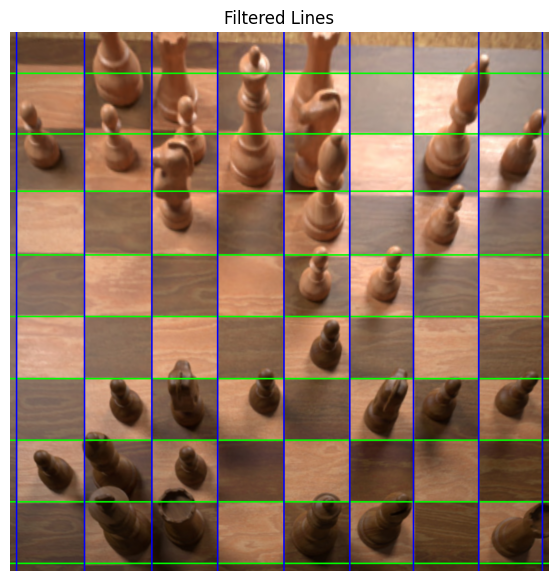

In [19]:
h, w = wrapped_image.shape[:2]

c_wrapped_horizontal_pos = collapse_and_average_lines(
    wrapped_horizontal_lines, 
    dimension_index=1, 
    grouping_threshold=15
)
c_wrapped_vertical_pos = collapse_and_average_lines(
    wrapped_vertical_lines, 
    dimension_index=0, 
    grouping_threshold=15
)

final_y_pos = filter_redundant_lines_no_averaging(c_wrapped_horizontal_pos)
final_x_pos = filter_redundant_lines_no_averaging(c_wrapped_vertical_pos)

final_h_lines = create_drawing_lines(final_y_pos, 1, w, h)
final_v_lines = create_drawing_lines(final_x_pos, 0, w, h)


show_image_debug("Filtered Lines", wrapped_image, Hlines=final_h_lines, Vlines=final_v_lines)


In [20]:
def generate_final_grid_points(final_x_pos, final_y_pos, grid_size=9):
    """
    Creates the final (9, 9, 2) grid matrix from the set of perfect X and Y coordinates.
    
    final_x_pos: 1D array of 9 unique X coordinates (vertical line positions).
    final_y_pos: 1D array of 9 unique Y coordinates (horizontal line positions).
    """
    
    if len(final_x_pos) != grid_size or len(final_y_pos) != grid_size:
        print(f"Error: Expected {grid_size} positions in each dimension, found {len(final_x_pos)} and {len(final_y_pos)}.")
        return None

    # 1. Use itertools.product to generate all (X, Y) pairs
    # Note: We iterate Y first (rows) then X (columns) to match common matrix notation (Row, Column)
    all_points = []
    
    # Iterate through all Y positions (rows)
    for y in final_y_pos:
        # Iterate through all X positions (columns)
        for x in final_x_pos:
            all_points.append([x, y])
            
    # 2. Convert to a structured NumPy array
    # The result is a (9, 9, 2) matrix where result[i, j] = [x, y]
    final_grid_matrix = np.array(all_points, dtype=np.float32).reshape(grid_size, grid_size, 2)
    
    return final_grid_matrix

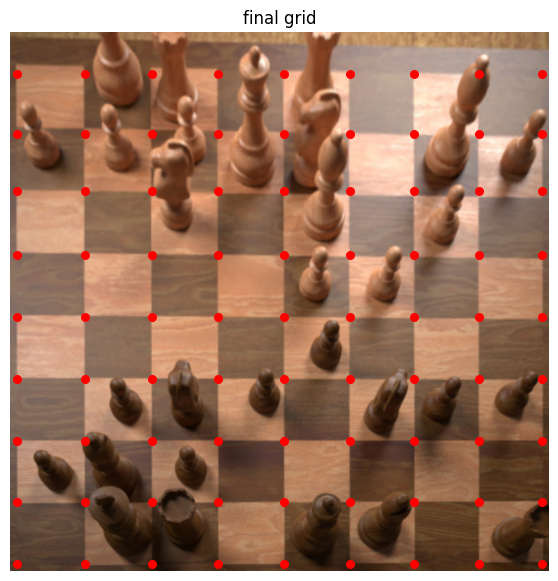

In [21]:
final_grid = generate_final_grid_points(final_x_pos,final_y_pos)
flat_points_array = final_grid.reshape(-1, 2)
show_image_debug("final grid",wrapped_image,points=flat_points_array)


### getting different pieces

In [22]:

def get_tile(x,y,grid,H_inv, original_image, margin=0.05):
    c1 = grid[y,x]
    c2 = grid[y,x+1]
    c3 = grid[y+1,x+1]
    c4 = grid[y+1,x]

    # 2. Pack them into the shape openCV expects: (N, 1, 2)
    flat_corners = np.array([c1, c2, c3, c4], dtype=np.float32).reshape(-1, 1, 2)
    orig_corners = cv2.perspectiveTransform(flat_corners, H_inv)
    # Remove the extra dimension -> (4, 2)
    pts = orig_corners.reshape(-1, 2)

    min_x, min_y = np.min(pts, axis=0)
    max_x, max_y = np.max(pts, axis=0)
    
    tile_w = max_x - min_x
    tile_h = max_y - min_y

    margin_w = tile_w * margin
    crop_w = int(tile_w + (2 * margin_w))
    crop_x = int(min_x - margin_w)

    # Height: Look UP from the bottom of the tile
    # The bottom of the piece is roughly at max_y. 
    # We want the crop to start higher up.
    margin_h = tile_h * margin
    crop_h = int(tile_h + (2 * margin_h))
    crop_y = int(min_y - margin_h)

    # 6. Safety Checks (Clamp to image boundaries)
    img_h, img_w = original_image.shape[:2]

    x1 = max(0, crop_x)
    y1 = max(0, crop_y)
    x2 = min(img_w, crop_x + crop_w)
    y2 = min(img_h, crop_y + crop_h)

    # 7. Perform the crop
    if x2 > x1 and y2 > y1:
        piece_img = original_image[y1:y2, x1:x2]
        return piece_img
    else:
        return None

def get_tile_wrapped(x,y,grid, wrapped_image, margin=0.05):
    c1 = grid[y,x]
    c2 = grid[y,x+1]
    c3 = grid[y+1,x+1]
    c4 = grid[y+1,x]

    pts =  np.array([c1, c2, c3, c4])
    min_x, min_y = np.min(pts, axis=0)
    max_x, max_y = np.max(pts, axis=0)
    
    tile_w = max_x - min_x
    tile_h = max_y - min_y

    margin_w = tile_w * margin
    crop_w = int(tile_w + (2 * margin_w))
    crop_x = int(min_x - margin_w)

    margin_h = tile_h * margin
    crop_h = int(tile_h + (2 * margin_h))
    crop_y = int(min_y - margin_h)

    img_h, img_w = wrapped_image.shape[:2]

    x1 = max(0, crop_x)
    y1 = max(0, crop_y)
    x2 = min(img_w, crop_x + crop_w)
    y2 = min(img_h, crop_y + crop_h)

    if x2 > x1 and y2 > y1:
        piece_img = wrapped_image[y1:y2, x1:x2]
        return piece_img
    else:
        return None


def get_piece(x,y,grid,H_inv, original_image, height_ratio=2):
    c1 = grid[y,x]
    c2 = grid[y,x+1]
    c3 = grid[y+1,x+1]
    c4 = grid[y+1,x]

    # 2. Pack them into the shape openCV expects: (N, 1, 2)
    flat_corners = np.array([c1, c2, c3, c4], dtype=np.float32).reshape(-1, 1, 2)
    orig_corners = cv2.perspectiveTransform(flat_corners, H_inv)
    # Remove the extra dimension -> (4, 2)
    pts = orig_corners.reshape(-1, 2)

    min_x, min_y = np.min(pts, axis=0)
    max_x, max_y = np.max(pts, axis=0)
    
    tile_w = max_x - min_x
    tile_h = max_y - min_y

    margin_w = tile_w * 0.05
    crop_w = int(tile_w + (2 * margin_w))
    crop_x = int(min_x - margin_w)

    # Height: Look UP from the bottom of the tile
    # The bottom of the piece is roughly at max_y. 
    # We want the crop to start higher up.
    crop_h = int(tile_h * height_ratio)
    crop_y = int(max_y - crop_h)

    # 6. Safety Checks (Clamp to image boundaries)
    img_h, img_w = original_image.shape[:2]

    x1 = max(0, crop_x)
    y1 = max(0, crop_y)
    x2 = min(img_w, crop_x + crop_w)
    y2 = min(img_h, crop_y + crop_h)

    # 7. Perform the crop
    if x2 > x1 and y2 > y1:
        piece_img = original_image[y1:y2, x1:x2]
        return piece_img
    else:
        return None


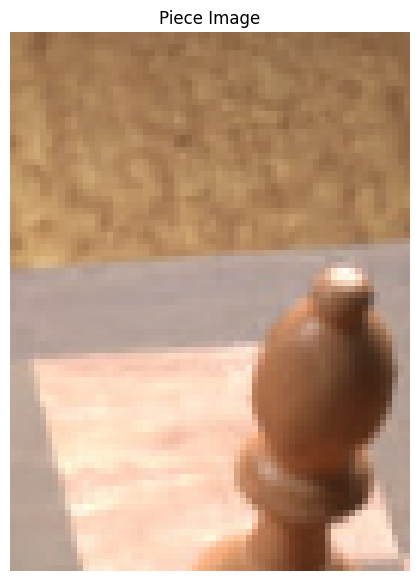

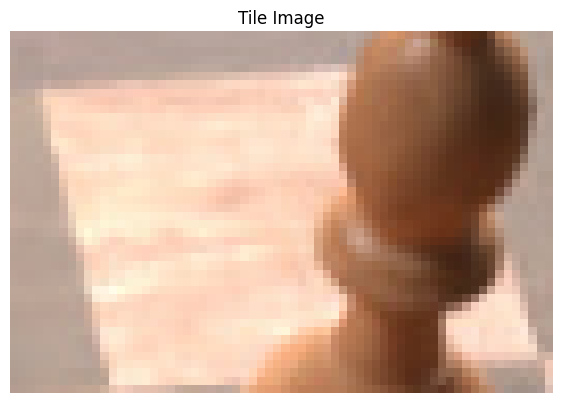

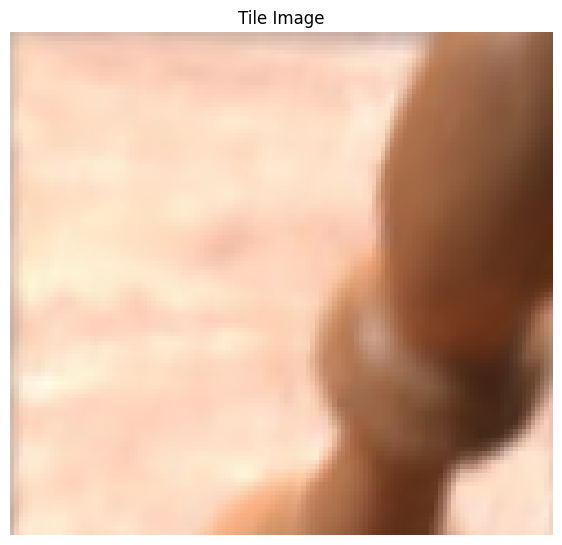

In [23]:
x = 6
y = 0

piece_image  = get_piece(x,y,final_grid,H_inv,image,height_ratio=2.2)
show_image_debug("Piece Image", piece_image)

tile_image  = get_tile(x,y,final_grid,H_inv,image,margin=0.05)
show_image_debug("Tile Image", tile_image)

tile_image_w  = get_tile_wrapped(x,y,final_grid,wrapped_image,margin=0)
show_image_debug("Tile Image", tile_image_w)

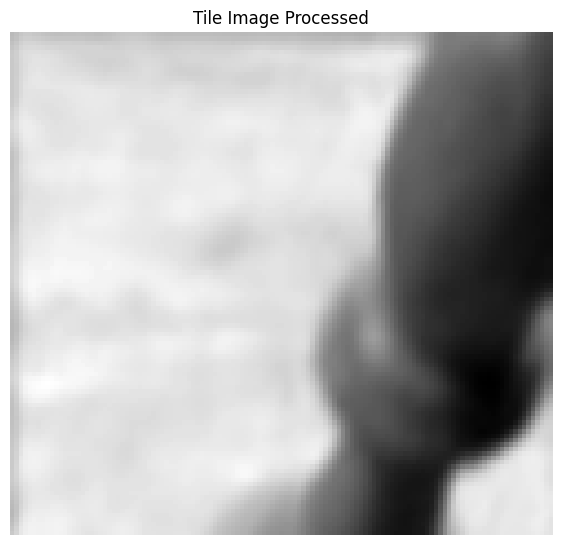

In [24]:
processed = cv2.cvtColor(tile_image_w, cv2.COLOR_BGR2GRAY)
processed = cv2.GaussianBlur(processed, (3,3), 0)

show_image_debug("Tile Image Processed", processed)

### General Info extraction

In [51]:
chess_board_filling = [True] * 81 

### Building 3d chess

In [52]:
class SimpleChessBoard3D:
    def __init__(self):
        """Simple 3D chess board generator - no camera calculations"""
        pass
    
    def get_tile_colors(self, get_tile_func, board_filling, board_size=9):
        """
        Extract average colors for light and dark tiles
        
        Args:
            get_tile_func: Function that returns tile image given (row, col)
            board_filling: List of bools indicating if tile is empty (True = empty)
            board_size: Size of the board (default 9 for 9x9)
        
        Returns:
            light_color: [r, g, b] for light tiles (0-255)
            dark_color: [r, g, b] for dark tiles (0-255)
        """
        light_colors = []
        dark_colors = []
        
        for row in range(board_size):
            for col in range(board_size):
                if board_filling[row][col]:  # Empty tile
                    tile_img = get_tile_func(row, col)
                    avg_color = np.mean(tile_img, axis=(0, 1))
                    
                    # Determine if light or dark tile (checkerboard pattern)
                    is_light = (row + col) % 2 == 0
                    
                    if is_light:
                        light_colors.append(avg_color)
                    else:
                        dark_colors.append(avg_color)
        
        # Average all collected colors
        light_color = np.mean(light_colors, axis=0).astype(int).tolist() if light_colors else [200, 200, 200]
        dark_color = np.mean(dark_colors, axis=0).astype(int).tolist() if dark_colors else [100, 100, 100]
        
        return light_color, dark_color
    
    def generate_html(self, 
                      light_color, 
                      dark_color,
                      board_filling,
                      board_size=9,
                      output_file="chess_board_3d.html"):
        """
        Generate simple Three.js HTML file with basic camera view
        
        Args:
            light_color: [r, g, b] for light tiles (0-255)
            dark_color: [r, g, b] for dark tiles (0-255)
            board_filling: List of bools (True = empty, False = occupied)
            board_size: Board dimensions (e.g., 9 for 9x9)
            output_file: Output HTML filename
        """
        
        # Convert RGB to hex
        light_hex = "0x{:02x}{:02x}{:02x}".format(*light_color)
        dark_hex = "0x{:02x}{:02x}{:02x}".format(*dark_color)
        
        html_content = f"""<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>3D Chess Board</title>
    <style>
        body {{ margin: 0; overflow: hidden; }}
        canvas {{ display: block; }}
        #info {{
            position: absolute;
            top: 10px;
            left: 10px;
            color: white;
            font-family: monospace;
            background: rgba(0,0,0,0.7);
            padding: 10px;
            border-radius: 5px;
        }}
    </style>
</head>
<body>
    <div id="info">Drag to rotate | Scroll to zoom</div>
    <script src="https://cdnjs.cloudflare.com/ajax/libs/three.js/r128/three.min.js"></script>
    <script>
        // Basic Three.js setup
        const scene = new THREE.Scene();
        scene.background = new THREE.Color(0x2a2a2a);
        
        // Camera - simple angled view
        const camera = new THREE.PerspectiveCamera(
            50,
            window.innerWidth / window.innerHeight,
            0.1,
            1000
        );
        camera.position.set(10, 12, 10);
        camera.lookAt(0, 0, 0);
        
        // Renderer
        const renderer = new THREE.WebGLRenderer({{ antialias: true }});
        renderer.setSize(window.innerWidth, window.innerHeight);
        renderer.shadowMap.enabled = true;
        document.body.appendChild(renderer.domElement);
        
        // Lights
        const ambientLight = new THREE.AmbientLight(0xffffff, 0.6);
        scene.add(ambientLight);
        
        const directionalLight = new THREE.DirectionalLight(0xffffff, 0.6);
        directionalLight.position.set(10, 20, 10);
        directionalLight.castShadow = true;
        scene.add(directionalLight);
        
        // Board colors
        const lightColor = {light_hex};
        const darkColor = {dark_hex};
        
        // Board data
        const boardSize = {board_size};
        const tileSize = 1;
        const boardFilling = {json.dumps(board_filling)};
        
        // Create board
        const boardGroup = new THREE.Group();
        
        let idx = 0;
        for (let row = 0; row < boardSize; row++) {{
            for (let col = 0; col < boardSize; col++) {{
                // Checkerboard pattern
                const isLight = (row + col) % 2 === 0;
                const color = isLight ? lightColor : darkColor;
                
                // Create tile
                const geometry = new THREE.BoxGeometry(tileSize, 0.2, tileSize);
                const material = new THREE.MeshStandardMaterial({{ 
                    color: color,
                    roughness: 0.7,
                    metalness: 0.1
                }});
                const tile = new THREE.Mesh(geometry, material);
                
                // Position (center the board)
                const x = col - boardSize/2 + 0.5;
                const z = row - boardSize/2 + 0.5;
                tile.position.set(x, 0, z);
                tile.receiveShadow = true;
                tile.castShadow = true;
                
                boardGroup.add(tile);
                
                // Add piece if occupied
                if (!boardFilling[idx]) {{
                    const pieceGeometry = new THREE.CylinderGeometry(0.3, 0.3, 0.8, 16);
                    const pieceMaterial = new THREE.MeshStandardMaterial({{ 
                        color: 0x444444,
                        roughness: 0.5,
                        metalness: 0.4
                    }});
                    const piece = new THREE.Mesh(pieceGeometry, pieceMaterial);
                    piece.position.set(x, 0.6, z);
                    piece.castShadow = true;
                    boardGroup.add(piece);
                }}
                
                idx++;
            }}
        }}
        
        scene.add(boardGroup);
        
        // Floor plane
        const floorGeometry = new THREE.PlaneGeometry(30, 30);
        const floorMaterial = new THREE.MeshStandardMaterial({{ 
            color: 0x1a1a1a,
            roughness: 0.9
        }});
        const floor = new THREE.Mesh(floorGeometry, floorMaterial);
        floor.rotation.x = -Math.PI / 2;
        floor.position.y = -0.2;
        floor.receiveShadow = true;
        scene.add(floor);
        
        // Simple mouse controls
        let isDragging = false;
        let previousMousePosition = {{ x: 0, y: 0 }};
        
        renderer.domElement.addEventListener('mousedown', (e) => {{
            isDragging = true;
            previousMousePosition = {{ x: e.clientX, y: e.clientY }};
        }});
        
        renderer.domElement.addEventListener('mousemove', (e) => {{
            if (isDragging) {{
                const deltaX = e.clientX - previousMousePosition.x;
                const deltaY = e.clientY - previousMousePosition.y;
                
                boardGroup.rotation.y += deltaX * 0.01;
                boardGroup.rotation.x += deltaY * 0.01;
                
                previousMousePosition = {{ x: e.clientX, y: e.clientY }};
            }}
        }});
        
        renderer.domElement.addEventListener('mouseup', () => {{
            isDragging = false;
        }});
        
        renderer.domElement.addEventListener('wheel', (e) => {{
            e.preventDefault();
            camera.position.z += e.deltaY * 0.01;
            camera.position.z = Math.max(5, Math.min(30, camera.position.z));
        }});
        
        // Animation loop
        function animate() {{
            requestAnimationFrame(animate);
            renderer.render(scene, camera);
        }}
        animate();
        
        // Handle window resize
        window.addEventListener('resize', () => {{
            camera.aspect = window.innerWidth / window.innerHeight;
            camera.updateProjectionMatrix();
            renderer.setSize(window.innerWidth, window.innerHeight);
        }});
    </script>
</body>
</html>"""
        
        with open(output_file, 'w') as f:
            f.write(html_content)
        
        print(f"✓ Generated {output_file}")
        print(f"  Board size: {board_size}x{board_size}")
        print(f"  Light color: RGB{tuple(light_color)}")
        print(f"  Dark color: RGB{tuple(dark_color)}")
        print(f"  Occupied tiles: {sum(1 for x in board_filling if not x)}")
        
        return output_file



generator = SimpleChessBoard3D()
def dummy_get_tile(row, col):
    #if (row + col) % 2 == 0:return np.ones((50, 50, 3)) * 220  # Light tile
    #else:return np.ones((50, 50, 3)) * 80   # Dark tile
    return get_tile_wrapped(row,col,final_grid,wrapped_image,margin=0)
    
 # 9x9 board with some pieces
board_filling = [[True] * 8] * 8
board_filling[0][3] = False
board_filling[1][3] = False
    
# Get colors
light_color, dark_color = generator.get_tile_colors(
    dummy_get_tile, 
    board_filling, 
    board_size=8
)
    
# Generate HTML
generator.generate_html(
    light_color=light_color,
    dark_color=dark_color,
    board_filling=board_filling,
    board_size=8,
    output_file="chess_board_3d.html"
)
    
print("\nOpen chess_board_3d.html in your browser!")

✓ Generated chess_board_3d.html
  Board size: 8x8
  Light color: RGB(90, 118, 164)
  Dark color: RGB(67, 87, 117)
  Occupied tiles: 0

Open chess_board_3d.html in your browser!
